### Capture Image using Picamera2 and plotting the result using pyplot from matplotlib

In [1]:
from picamera2 import Picamera2
# picamera2 offers two alternatives, capture images as numpy arrays or capture images as PIL.Images
import cv2
import numpy as np
import PIL                              # import pillow library as an alternative to store images
import matplotlib.pyplot as plt
import time

In [2]:
# Create one object per camera, otherwise will yield resource busy error.
picam2 = Picamera2()

[0:48:29.421632434] [3507]  INFO Camera camera_manager.cpp:284 libcamera v0.1.0+118-563cd78e
[0:48:29.459244344] [3522]  WARN RPiSdn sdn.cpp:39 Using legacy SDN tuning - please consider moving SDN inside rpi.denoise
[0:48:29.462181181] [3522]  INFO RPI vc4.cpp:444 Registered camera /base/soc/i2c0mux/i2c@1/ov5647@36 to Unicam device /dev/media3 and ISP device /dev/media0
[0:48:29.462246569] [3522]  INFO RPI pipeline_base.cpp:1142 Using configuration file '/usr/share/libcamera/pipeline/rpi/vc4/rpi_apps.yaml'
[0:48:29.471232265] [3507]  INFO Camera camera_manager.cpp:284 libcamera v0.1.0+118-563cd78e
[0:48:29.507873278] [3525]  WARN RPiSdn sdn.cpp:39 Using legacy SDN tuning - please consider moving SDN inside rpi.denoise
[0:48:29.510489656] [3525]  INFO RPI vc4.cpp:444 Registered camera /base/soc/i2c0mux/i2c@1/ov5647@36 to Unicam device /dev/media3 and ISP device /dev/media0
[0:48:29.510566266] [3525]  INFO RPI pipeline_base.cpp:1142 Using configuration file '/usr/share/libcamera/pipeline

In [25]:
config = picam2.create_preview_configuration()
picam2.configure(config)

[0:56:08.648779010] [3529]  INFO Camera camera.cpp:1183 configuring streams: (0) 640x480-XBGR8888 (1) 640x480-SGBRG10_CSI2P
[0:56:08.651118002] [3525]  INFO RPI vc4.cpp:608 Sensor: /base/soc/i2c0mux/i2c@1/ov5647@36 - Selected sensor format: 640x480-SGBRG10_1X10 - Selected unicam format: 640x480-pGAA


In [26]:
# camera_config = picam2.create_still_configuration(main={"size": (1920, 1080)}, lores={"size": (640, 480)}, display="lores")
# picam2.configure(camera_config)

In [27]:
# Applies configuration to camera and sets it up to start capturing images.
# If this line is not executed, the picam2.capture_* methods won't work.
picam2.start()

In [35]:
# Capture a single image as numpy array.
img_array = picam2.capture_array("main")
# Format: (height, width, 4) for 4 channel XBGR (alpha) type formats
# height = num. rows, width = num. cols in pixels.
print(img_array.shape)

(480, 640, 4)


In [36]:
# pytplot expects RGB format and the format of our image is XBGR.
# We can use OpenCV to re-order the image channels into the appropriate format
# for our usecase.
# img_array[:,:,0:3] means select all the rows, all the columns and select from channel 0 until channel 3 (RGB) (the BGR channels) excluding channel 4 = X (or alpha channel)
rgb_image = cv2.cvtColor(img_array[:,:,0:3], cv2.COLOR_BGR2RGB)
print(rgb_image.shape)

(480, 640, 3)


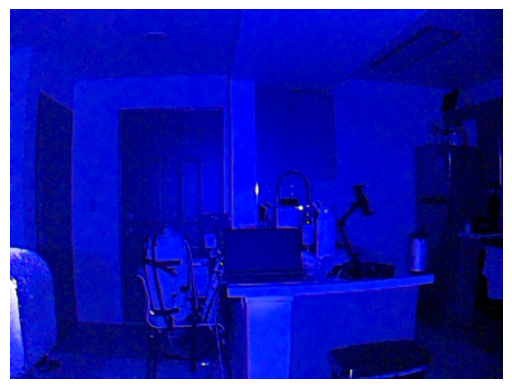

In [37]:
# Display the original image (XBGR)
# plt.imshow expects an image in RGB format but it received
# the channels flipped so it is assuming that the B channel is the
# R channel, which is why the image looks Bluish in night time.
plt.imshow(img_array)
plt.axis('off')  # To hide axis labels
plt.show()

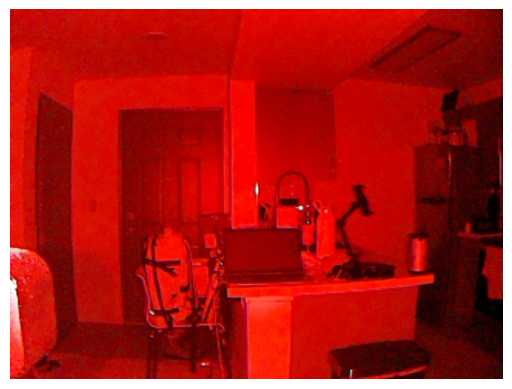

In [38]:
# Display the RGB image
# For night-time picutres this will look Redish because the
# sensor automatically switches to producing intensity values for infrared.
# read more below.
plt.imshow(rgb_image)
plt.axis('off')  # To hide axis labels
plt.show()

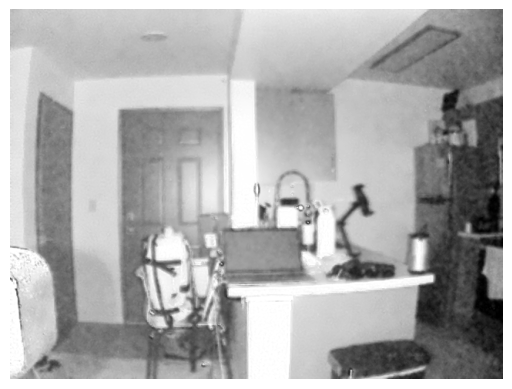

In [47]:
# For night vision we select the R channel from the img_array in BGR format.
# and display it as a grayscale image. Why? we're using infrared light,
# not color light (different spectrums). We use cmap='gray' to tell
# matplotlib that this is a single-channel image and to use the grayscale
# to display it.
plt.imshow(img_array[:,:,2], cmap='gray')
plt.axis('off')  # To hide axis labels
plt.show()

In [39]:
# Capture image as PIL.Image
pil_image = picam2.capture_image("main")

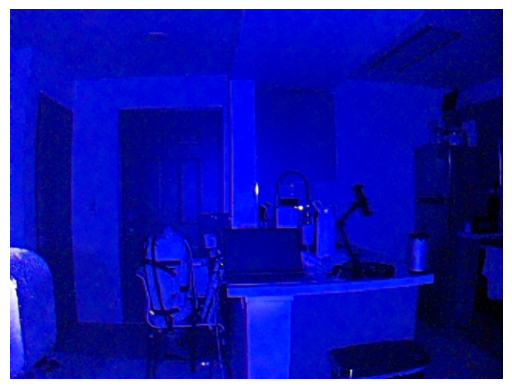

In [40]:
# Convert the Pillow image to a NumPy array (stil XBGR image here)
pil_image_array = np.array(pil_image)

# Display the image
plt.imshow(pil_image_array)
plt.axis('off')  # This hides the axis labels
plt.show()

In [41]:
# Disable the capturing state of the sensor. Good practice when you're not using the camera to capture anymore.
# After calling this method, you must call start() again.
picam2.stop()

### Image De-Noise

In [48]:
picam2.start()

In [49]:
frame_rate = 1/30       # seconds/img -> how much time to wait between taking pictures
num_imgs = 5            # num of images to take

In [50]:
img_list = []   # initialize an empty image list
for _ in range(0, num_imgs):        # the _ means ignore the index value because we won't use it in the for loop
    img_array = picam2.capture_array("main")        # Capture an image
    # img_list.append(cv2.cvtColor(img_array[:,:,0:3], cv2.COLOR_BGR2RGB))    # Use this line during daytime
    img_list.append(img_array[:,:,2])                                       # Use this line during night time or low light conditions -> Only add the R channel to the list
    time.sleep(frame_rate)                          # Wait a bit before taking next image.

In [51]:
# Convert the list of images to a 4D NumPy array (num_images, height, width, channels)
stacked_images = np.array(img_list)

# Apply temporal denoising by averaging the images
denoised_image = np.mean(stacked_images, axis=0)

# The result is a single image (NumPy array) with reduced noise
# You might need to ensure the data type is correct, e.g., uint8 for display
denoised_image = np.clip(denoised_image, 0, 255).astype(np.uint8)

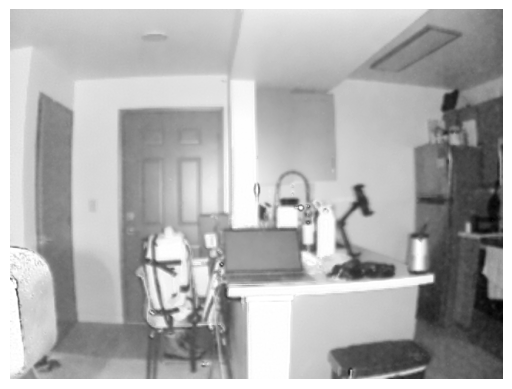

In [52]:
# This image is the average of the "num_imgs" taken. Averaging
# reduces "noise" in images, which is why this one looks sharper
# than the previous one we captured.
plt.imshow(denoised_image, cmap='gray')     # Night Time
# plt.imshow(denoised_image)                  # Daytime Time
plt.axis('off')  # To hide axis labels
plt.show()